In [94]:
import torch
import torch.nn.functional as F
import random
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# --- Extended MLP ---
# Main differences: weight initialization, batch normalization

In [96]:
with open("names.txt", "r") as f:
    words = f.read().splitlines()

chars = sorted(list(set("".join(words))))
stoi = {c:i + 1 for i, c in enumerate(chars)} # {".":0, "a":1, ...}
stoi["."] = 0
itos = {i:c for c, i in stoi.items()} # {0:".", 1:"a", ...}

In [97]:
block_size = 3

def build_dataset(words):
    X, Y = [], []
    for word in words:
        context = [0] * block_size
        for ch in word + ".":
            idx = stoi[ch]
            X.append(context)
            Y.append(idx)
            context = context[1:] + [idx]
    return torch.tensor(X), torch.tensor(Y)

# Training/dev/test = 0.8/0.1/0.1
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

Xtr.shape

torch.Size([182581, 3])

In [98]:
n_embd = 10 # Dimensionality of character embedding vectors
n_hidden = 200 # No. of neurons in the hidden layer
vocab_size = len(itos)

C = torch.randn(vocab_size, n_embd) # Embedding matrix (10D)

# Fix tanh saturation
W1 = torch.randn(n_embd * block_size, n_hidden) * (5/3)/((n_embd * block_size)**0.5) # Kaiming init (gain/sqrt(fan_in))

# Fix initial loss
W2 = torch.randn(n_hidden, vocab_size) * 0.01 # Non-zero for symmetry breaking
b2 = torch.randn(vocab_size) * 0 

# BatchNorm (learned shift, running mean/std)
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2] # Easy access for parameters

In [99]:
# Track with autograd
for p in parameters:
  p.requires_grad = True
    
sum(p.nelement() for p in parameters) # Total no. of parameters

11697

      0/ 200000: 3.2907
  10000/ 200000: 2.1194
  20000/ 200000: 2.3983
  30000/ 200000: 2.2311
  40000/ 200000: 2.3085
  50000/ 200000: 2.2508
  60000/ 200000: 2.5551
  70000/ 200000: 2.2588
  80000/ 200000: 2.2665
  90000/ 200000: 2.4594
 100000/ 200000: 2.2719
 110000/ 200000: 2.0955
 120000/ 200000: 2.1825
 130000/ 200000: 2.0134
 140000/ 200000: 2.3713
 150000/ 200000: 2.0943
 160000/ 200000: 1.6475
 170000/ 200000: 2.0096
 180000/ 200000: 1.8485
 190000/ 200000: 2.2896


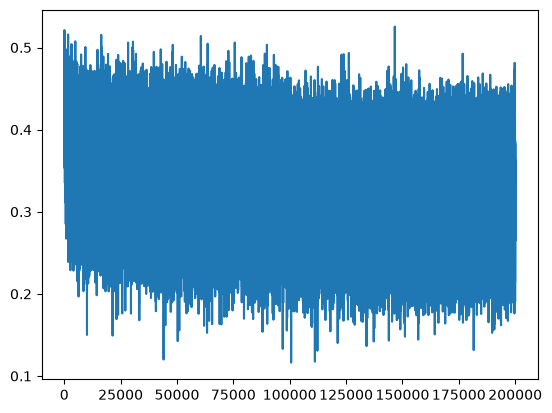

In [ ]:
max_steps = 200000
batch_size = 32
lossi = []


for i in range(max_steps):

    # Mini-batch construction
    idx = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[idx], Ytr[idx]
    
    # Preactivation layer
    emb = C[Xb] # Embed the context into vectors
    x = emb.view(emb.shape[0], -1) # Concatenate the vectors
    hpreact = x @ W1 # Hidden layer pre-activation (remove spurious b1 with BatchNorm)

    # BatchNorm layer
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias # BatchNorm (bnbias replaces b1's effect)
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

    # Non-linearity layer
    h = torch.tanh(hpreact) # Hidden layer (32, 200)
    logits = h @ W2 + b2 # Output layer (32, 27)
    loss = F.cross_entropy(logits, Yb)

    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update weights
    lr = 0.1 if i < 100000 else 0.01 # Learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0: # Print every 10k steps
        print(f"{i:7d}/{max_steps:7d}: {loss.item():.4f}")
    lossi.append(loss.log10().item())

plt.plot(lossi)

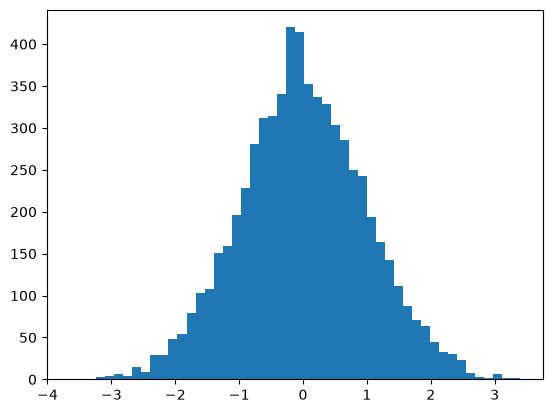

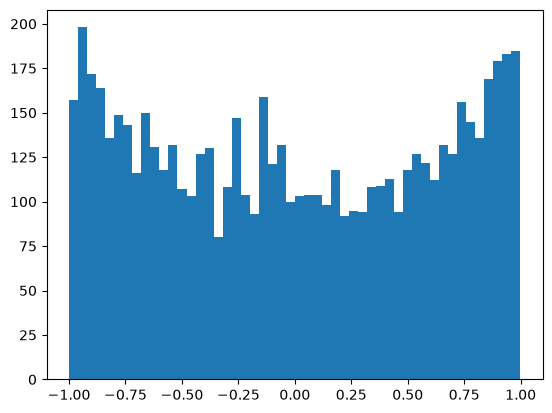

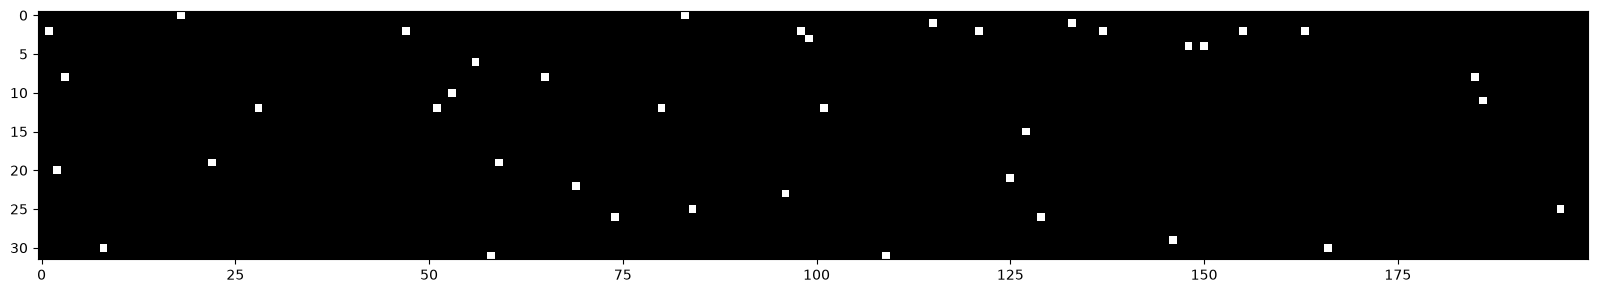

In [101]:
# Pre-activations
plt.figure()
plt.hist(hpreact.view(-1).tolist(), 50)
plt.show()

# Activations
plt.figure()
plt.hist(h.view(-1).tolist(), 50)
plt.show()

# Show activations > 0.99 as white
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap="gray", interpolation="nearest")

In [102]:
@torch.no_grad() # Disable gradient tracking (less work + memory)

# Find loss on train/val/test
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split] # Initialize dict and index simultaneously
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # Concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 # Hidden layer pre-activation (32, 200)
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias # BatchNorm
  h = torch.tanh(hpreact) # Hidden layer (32, 200)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0787534713745117
val 2.1138916015625


In [ ]:
"""
# Loss log

# Original
train 2.1150004863739014
val 2.17510986328125

# Fix initial loss (smaller W2/b2)
train 2.074284791946411
val 2.1515374183654785

# Fix saturated tanh (smaller W1/b1)
train 2.0384342670440674
val 2.097444772720337

# Add Kaiming init
train 2.0393221378326416
val 2.1049516201019287

# Add BatchNorm
train 2.075690746307373
val 2.1204686164855957
"""

'\n# Loss log\n\n# Original\ntrain 2.1150004863739014\nval 2.17510986328125\n\n# Fix initial loss (smaller W2/b2)\ntrain 2.074284791946411\nval 2.1515374183654785\n\n# Fix saturated tanh (smaller W1/b1)\ntrain 2.0384342670440674\nval 2.097444772720337\n\n'

In [ ]:
# --- PyTorchify-ed version ---
# Main differences: show how PyTorch-style modularity works, visualize NN internals to show how BatchNorm stabilizes training (+ removes much of the need for Kaiming init)

In [ ]:
# All modules (roughly) match PyTorch implementations + interfaces

class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # Kaiming init
        self.bias = torch.zeros(fan_out) if bias else None
    
    def __call__(self, x):
        self.out = x @ self.weight # Store self.out for visualizations
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps # Added for numerical stability (?)
        self.momentum = momentum # Higher momentum –> more weight on current batch
        self.training = True # Training vs inference mode
        self.gamma = torch.ones(dim) # aka "bngain"
        self.beta = torch.zeros(dim) # aka "bnbias"
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True)

            # Update running mean + var
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        else:
            xmean = self.running_mean
            xvar = self.running_var

        # Normalize
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []

In [166]:
n_embd = 10
n_hidden = 100

C = torch.randn((vocab_size, n_embd))

# 6 hidden layers (each hidden layer = linear –> BatchNorm –> non-linear)
layers = [
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(          n_hidden , n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(          n_hidden , n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(          n_hidden , n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(          n_hidden , n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(          n_hidden , vocab_size, bias=False), BatchNorm1d(vocab_size),
]

# Make adjustments to initial weights
with torch.no_grad():
    # layers[-1].gamma *= 0.1 # Make outputs less confident (similar to fixing W2)
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 1 # Gain for Kaiming init (no effect with 1.0)

parameters = [C] + [p for layer in layers for p in layer.parameters()]
for p in parameters:
    p.requires_grad = True

print(sum(p.nelement() for p in parameters))

47024


      0/ 200000: 3.7211


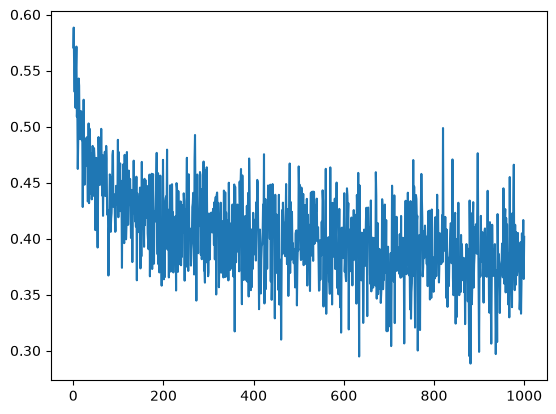

In [ ]:
# Same optimization as above

max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

    # Mini-batch construction
    idx = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[idx], Ytr[idx]
    
    # Forward pass
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)

    # Backward pass
    for layer in layers:
        layer.out.retain_grad() # Store intermediate tensor grads for visualizations
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update weights
    lr = 0.1 if i < 100000 else 0.01 # Learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # Track stats (every 10k steps)
    if i % 10000 == 0:
        print(f"{i:7d}/{max_steps:7d}: {loss.item():.4f}")
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters]) # Update-to-data ratio (i.e. how big update is relative to current weight)

    # NOTE: break early for testing purposes only
    if i >= 1000:
        break

plt.plot(lossi)

layer 2 (      Tanh): mean +0.01, std 0.64, saturated: 2.91%
layer 5 (      Tanh): mean +0.00, std 0.64, saturated: 2.69%
layer 8 (      Tanh): mean -0.00, std 0.65, saturated: 2.44%
layer 11 (      Tanh): mean +0.00, std 0.65, saturated: 2.06%
layer 14 (      Tanh): mean -0.01, std 0.66, saturated: 1.44%


Text(0.5, 1.0, 'Activation distribution')

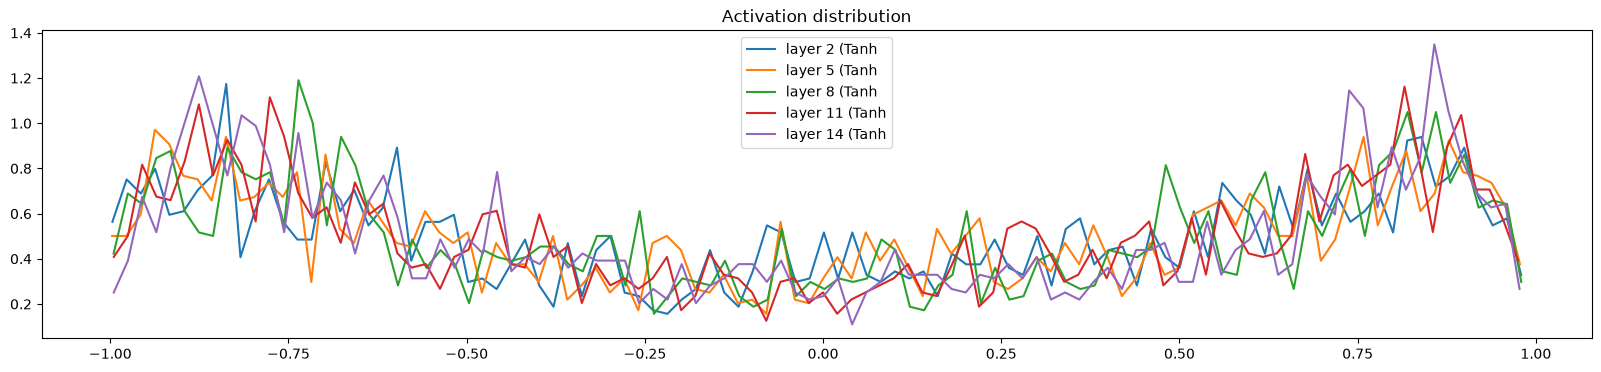

In [168]:
# Activation distribution
# Goal: Avoid extreme outputs, which kills gradients (1 - tanh^2), and collapse to 0
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers[:-1]):
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('Activation distribution')

layer 2 (      Tanh): mean +0.000000, std 3.226785e-03
layer 5 (      Tanh): mean -0.000000, std 2.354349e-03
layer 8 (      Tanh): mean -0.000000, std 2.071710e-03
layer 11 (      Tanh): mean +0.000000, std 1.962605e-03
layer 14 (      Tanh): mean -0.000000, std 2.070490e-03


Text(0.5, 1.0, 'Activation gradient distribution')

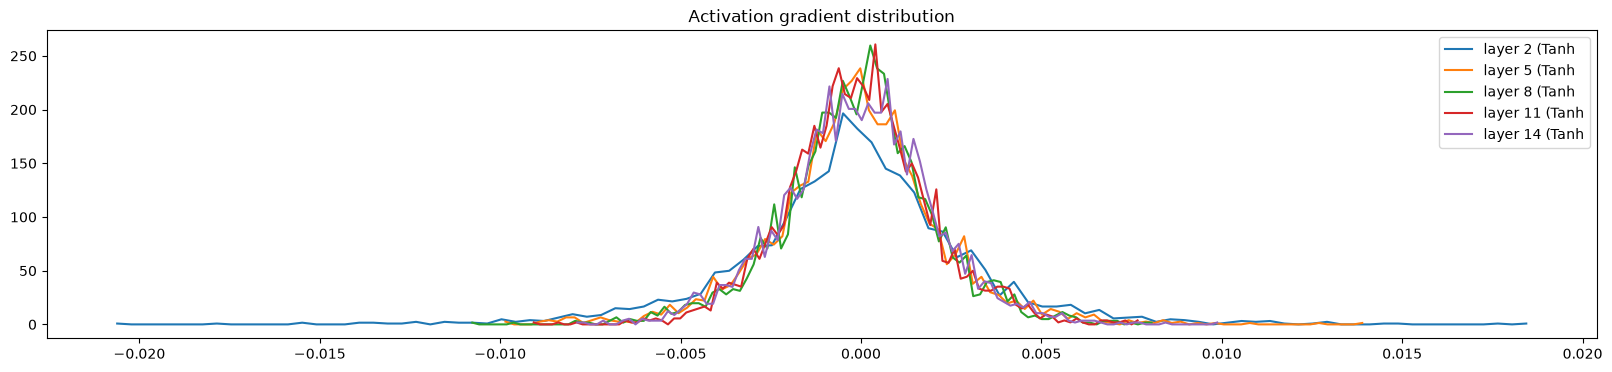

In [169]:
# Gradient distribution (on Tanh layers)
# Goal: Avoid vanishing/exploding gradients as layers get deeper
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers[:-1]):
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('Activation gradient distribution')

weight   (27, 10) | mean -0.000000 | std 7.661642e-03 | grad:data ratio 7.308455e-03
weight  (30, 100) | mean -0.000302 | std 1.105205e-02 | grad:data ratio 5.905283e-02
weight (100, 100) | mean -0.000368 | std 7.800121e-03 | grad:data ratio 7.531705e-02
weight (100, 100) | mean -0.000040 | std 6.410301e-03 | grad:data ratio 6.239776e-02
weight (100, 100) | mean -0.000046 | std 5.484174e-03 | grad:data ratio 5.332365e-02
weight (100, 100) | mean +0.000071 | std 5.126184e-03 | grad:data ratio 5.009383e-02
weight  (100, 27) | mean -0.000131 | std 1.024716e-02 | grad:data ratio 9.394848e-02


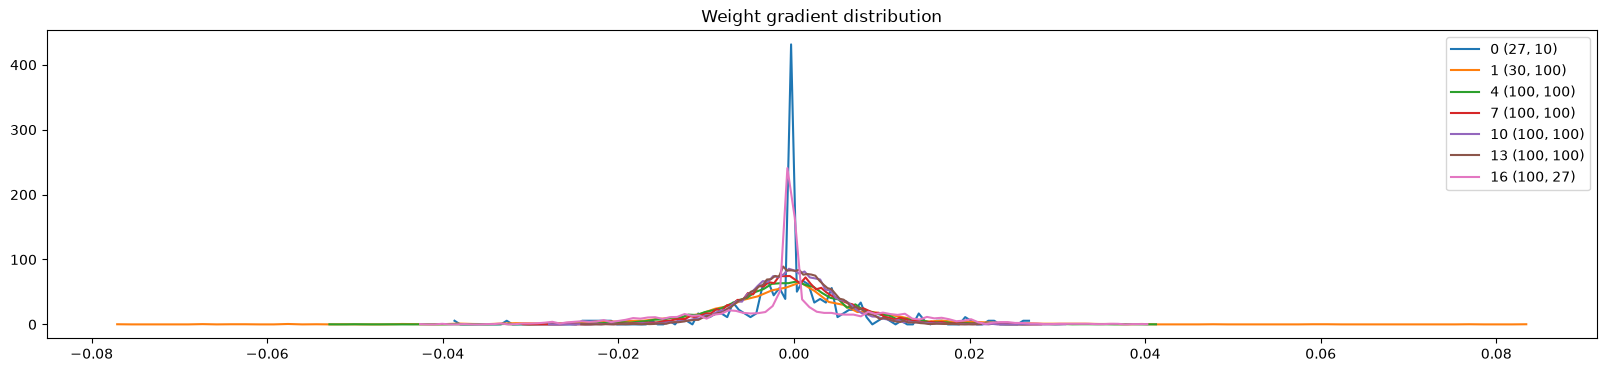

In [170]:
# Gradient distribution (on linear layers)
# Goal: Check that gradient magnitudes are reasonably sized and balanced
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std())) # 
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('Weight gradient distribution');

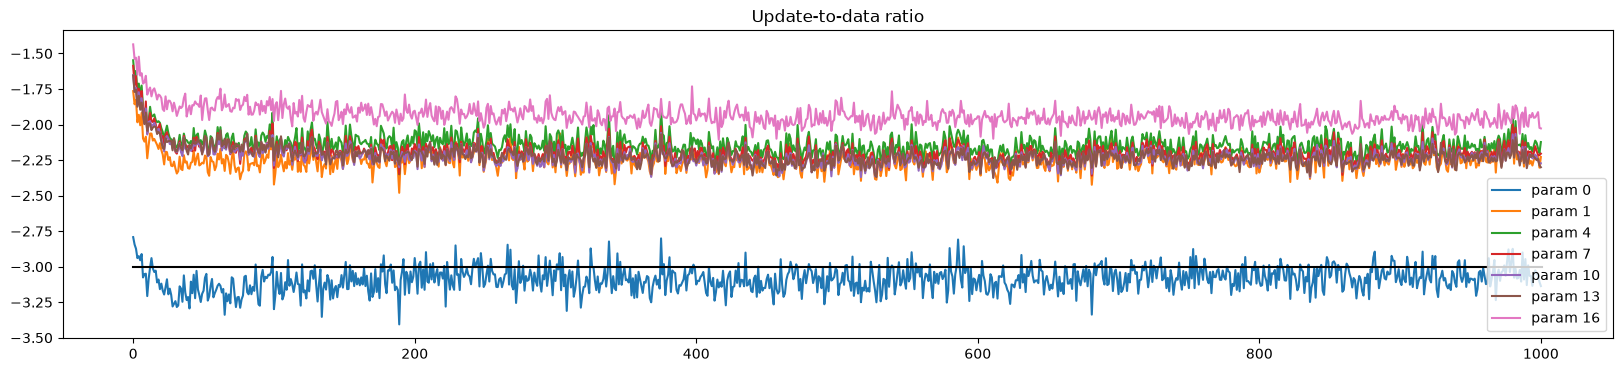

In [171]:
# Update-to-data ratio over time
# Goal: Keep relative update size stable (~1e-3, marked on plot)
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k')
plt.legend(legends)
plt.title('Update-to-data ratio');